# 06 — Ensemble & Threshold Tuning — **UPDATED**

**Changes:** Loads global `label_encoders.json` from NB05 so abuse_type y_true
matches the 9-class logits. Saves `ensemble_test_metrics.json` for NB07.


In [10]:
import os, json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from sklearn.metrics import (f1_score, accuracy_score, matthews_corrcoef,
    classification_report, confusion_matrix, roc_auc_score, average_precision_score)
from sklearn.linear_model import LogisticRegression
from scipy.optimize import minimize_scalar, minimize

warnings.filterwarnings("ignore")
os.makedirs("../outputs/ensemble", exist_ok=True)


In [11]:
MODELS_DIR = "../outputs/models_v2_fix"

model_dirs = sorted(glob.glob(f"{MODELS_DIR}/*_seed*"))
print(f"Found {len(model_dirs)} model runs:")
for d in model_dirs: print(f"  {os.path.basename(d)}")

val_logits_all  = {}
test_logits_all = {}

for d in model_dirs:
    name = os.path.basename(d)
    vp   = os.path.join(d, "val_logits.pt")
    tp   = os.path.join(d, "test_logits.pt")
    if os.path.exists(vp) and os.path.exists(tp):
        val_logits_all[name]  = torch.load(vp,  map_location="cpu", weights_only=False)
        test_logits_all[name] = torch.load(tp, map_location="cpu", weights_only=False)
        tasks_avail = list(val_logits_all[name].keys())
        print(f"  ✅ {name}  tasks={tasks_avail}")
    else:
        print(f"  ⚠ {name} — logit files missing, skipping")

print(f"\nLoaded {len(val_logits_all)} runs")


Found 9 model runs:
  banglabert_seed123
  banglabert_seed42
  banglabert_seed456
  muril_seed123
  muril_seed42
  muril_seed456
  xlmr_seed123
  xlmr_seed42
  xlmr_seed456
  ✅ banglabert_seed123  tasks=['binary', 'abuse_type']
  ✅ banglabert_seed42  tasks=['binary', 'abuse_type']
  ✅ banglabert_seed456  tasks=['binary', 'abuse_type']
  ✅ muril_seed123  tasks=['binary', 'abuse_type']
  ✅ muril_seed42  tasks=['binary', 'abuse_type']
  ✅ muril_seed456  tasks=['binary', 'abuse_type']
  ✅ xlmr_seed123  tasks=['binary', 'abuse_type']
  ✅ xlmr_seed42  tasks=['binary', 'abuse_type']
  ✅ xlmr_seed456  tasks=['binary', 'abuse_type']

Loaded 9 runs


In [12]:
# ── Load true labels + apply same consolidation as NB05 ────────────
# CRITICAL: NB05 saves logits for 9 consolidated classes.
# val_df / test_df here have RAW label_type (89 classes) unless we apply the
# same consolidate_type function. We load label_encoders.json to stay in sync.

SPLIT_DIR = "../data/splits"
val_df    = pd.read_csv(f"{SPLIT_DIR}/random_val.csv")
test_df   = pd.read_csv(f"{SPLIT_DIR}/random_test.csv")

# ── Load global label encoders saved by NB05 ───────────────────────
LE_PATH = f"{MODELS_DIR}/label_encoders.json"
assert os.path.exists(LE_PATH), (
    f"label_encoders.json not found at {LE_PATH}. "
    "Run NB05 first and make sure it completes the consolidation cell."
)
with open(LE_PATH) as _f:
    _raw_le = json.load(_f)

# NB05 saves integer keys for binary as strings; restore proper types
label_encoders = {}
for task, enc in _raw_le.items():
    if task == "binary":
        label_encoders[task] = {int(k): v for k, v in enc.items()}
    else:
        label_encoders[task] = enc      # abuse_type keys are strings

# ── Apply same consolidation ────────────────────────────────────────
TYPE_MAP = {
    "none":"none","not bully":"none",
    "threat":"threat","threat,spam":"threat",
    "callToViolence":"threat","callToViolence_slander":"threat",
    "callToViolence_gender":"threat","callToViolence_religion":"threat",
    "callToViolence_religion_slander":"threat",
    "callToViolence_gender_religion_slander":"threat",
    "callToViolence_gender_slander":"threat",
    "religious,threat":"threat","sexual,threat":"threat","sexual,religious,threat":"threat",
    "sexual":"sexual","sexual,religious":"sexual","sexual,spam":"sexual",
    "religious":"religious","Religious":"religious","religion":"religious",
    "religious,spam":"religious","religion_slander":"religious",
    "gender_religion":"religious","gender_religion_slander":"religious",
    "gender":"gender","Gender":"gender","gender_slander":"gender",
    "Political":"political",
    "Personal Offense":"personal","Body Shaming":"personal",
    "Origin":"personal","slander":"personal","Misc":"personal",
    "Abusive/Violence":"abusive","troll":"abusive",
    "spam":"other",
}
PRIORITY = ["threat","sexual","religious","gender","political","abusive","personal","other","none"]

def consolidate_type(val):
    if not isinstance(val, str) or not val.strip(): return "none"
    val = val.strip()
    if val in TYPE_MAP: return TYPE_MAP[val]
    parts = [p.strip() for p in val.replace(";",",").split(",")]
    cands = [TYPE_MAP[p] for p in parts if p in TYPE_MAP]
    if cands:
        for pc in PRIORITY:
            if pc in cands: return pc
    sl = val.lower().replace("_"," ")
    for kw, cls in [("threat","threat"),("calltoviolence","threat"),("sexual","sexual"),
                    ("religious","religious"),("religion","religious"),("gender","gender"),
                    ("political","political"),("abusive","abusive"),("violence","abusive"),
                    ("personal","personal"),("slander","personal"),("origin","personal"),
                    ("body","personal"),("misc","personal"),("spam","other")]:
        if kw in sl.replace(" ",""): return cls
    return "other"

for df_ in [val_df, test_df]:
    df_["label_type"] = df_["label_type"].apply(consolidate_type)

# ── True labels (integer encoded) ──────────────────────────────────
y_val_binary  = val_df["label_binary"].values
y_test_binary = test_df["label_binary"].values

# abuse_type: encode consolidated strings → integers using NB05's mapping
abuse_enc = label_encoders["abuse_type"]
y_val_abuse  = np.array([abuse_enc.get(str(v), -1) for v in val_df["label_type"]])
y_test_abuse = np.array([abuse_enc.get(str(v), -1) for v in test_df["label_type"]])

print(f"Val  size: {len(val_df):,}   binary classes: {np.unique(y_val_binary)}")
print(f"Test size: {len(test_df):,}   abuse classes : {np.unique(y_val_abuse[y_val_abuse>=0])}")
print(f"abuse_type encoder: {abuse_enc}")


Val  size: 13,557   binary classes: [0 1]
Test size: 13,558   abuse classes : [0 1 2 3 4 5 6 7 8]
abuse_type encoder: {'abusive': 0, 'gender': 1, 'none': 2, 'other': 3, 'personal': 4, 'political': 5, 'religious': 6, 'sexual': 7, 'threat': 8}


## 1 — Weighted Logits Ensemble (binary task)

In [13]:
def ensemble_logits(logits_dict, weights, task="binary"):
    names = list(logits_dict.keys())
    assert len(weights) == len(names)
    out = None
    for i, name in enumerate(names):
        l = logits_dict[name][task].float()
        out = weights[i] * l if out is None else out + weights[i] * l
    return out / sum(weights)


def optimize_weights(val_logits_dict, y_true, task="binary", n_cls=2):
    names = list(val_logits_dict.keys())
    n     = len(names)

    def neg_f1(raw_w):
        w = np.abs(raw_w) + 1e-8
        ens = ensemble_logits(val_logits_dict, w, task)
        preds = ens.argmax(-1).numpy()
        return -f1_score(y_true, preds, average="macro", zero_division=0)

    best_val, best_w = 1.0, None
    for _ in range(50):
        w0 = np.random.dirichlet(np.ones(n))
        res = minimize(neg_f1, w0, method="Nelder-Mead",
                       options={"maxiter": 2000, "xatol": 1e-5})
        if res.fun < best_val:
            best_val, best_w = res.fun, np.abs(res.x) + 1e-8

    best_w = best_w / best_w.sum()
    print(f"Optimised {task} ensemble weights (sum=1):")
    for name, w in zip(names, best_w):
        print(f"  {name}: {w:.4f}")
    print(f"Val macro-F1 (optimised): {-best_val:.4f}")
    return best_w


if len(val_logits_all) == 0:
    print("❌ No logits loaded — run NB05 first")
    opt_weights = None
else:
    print("Optimising ensemble weights on validation set...")
    opt_weights = optimize_weights(val_logits_all, y_val_binary, "binary")


Optimising ensemble weights on validation set...
Optimised binary ensemble weights (sum=1):
  banglabert_seed123: 0.0422
  banglabert_seed42: 0.2817
  banglabert_seed456: 0.1163
  muril_seed123: 0.1187
  muril_seed42: 0.1680
  muril_seed456: 0.0664
  xlmr_seed123: 0.0107
  xlmr_seed42: 0.0336
  xlmr_seed456: 0.1625
Val macro-F1 (optimised): 0.9264


## 2 — Threshold Tuning

Best threshold: 0.50  val macro-F1: 0.9264
Default (0.50) val macro-F1: 0.9264


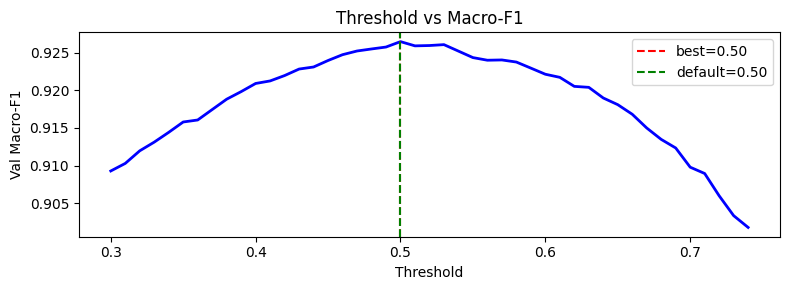

In [14]:
if opt_weights is not None:
    ens_logits_val = ensemble_logits(val_logits_all, opt_weights, "binary")
    ens_probs_val  = F.softmax(ens_logits_val, -1)[:, 1].numpy()

    thresholds = np.arange(0.30, 0.75, 0.01)
    f1s = [f1_score(y_val_binary, (ens_probs_val >= t).astype(int),
                    average="macro", zero_division=0) for t in thresholds]

    best_thresh   = float(thresholds[np.argmax(f1s)])
    best_thresh_f1 = float(max(f1s))
    print(f"Best threshold: {best_thresh:.2f}  val macro-F1: {best_thresh_f1:.4f}")
    print(f"Default (0.50) val macro-F1: {f1s[list(thresholds).index(0.50) if 0.50 in thresholds else np.argmin(np.abs(thresholds-0.50))]:.4f}")

    fig, ax = plt.subplots(figsize=(8,3))
    ax.plot(thresholds, f1s, "b-", linewidth=2)
    ax.axvline(best_thresh, color="r", linestyle="--", label=f"best={best_thresh:.2f}")
    ax.axvline(0.50,        color="g", linestyle="--", label="default=0.50")
    ax.set_xlabel("Threshold"); ax.set_ylabel("Val Macro-F1")
    ax.legend(); ax.set_title("Threshold vs Macro-F1")
    plt.tight_layout()
    plt.savefig("../outputs/ensemble/threshold_tuning.png", dpi=120, bbox_inches="tight")
    plt.show()


## 3 — Optional Stacking Meta-Learner

In [15]:
if len(val_logits_all) > 1 and opt_weights is not None:
    val_feat  = torch.cat([val_logits_all[n]["binary"]  for n in val_logits_all], -1).numpy()
    test_feat = torch.cat([test_logits_all[n]["binary"] for n in test_logits_all], -1).numpy()
    print(f"Stacking feature dim: {val_feat.shape[1]}")

    meta = LogisticRegression(C=1.0, max_iter=2000, class_weight="balanced", random_state=42)
    meta.fit(val_feat, y_val_binary)
    stack_val_f1 = f1_score(y_val_binary, meta.predict(val_feat), average="macro", zero_division=0)
    print(f"Stacking val macro-F1: {stack_val_f1:.4f}")
    print("(Stacking uses val for training; may over-fit — compare carefully with ensemble on test)")
else:
    print("Stacking skipped (need ≥2 models)")
    meta = None


Stacking feature dim: 18


Stacking val macro-F1: 0.9246
(Stacking uses val for training; may over-fit — compare carefully with ensemble on test)


## 4 — Final Test Evaluation

FINAL ENSEMBLE RESULTS — TEST SET

  Default (0.50)
    Accuracy=0.9256  Macro-F1=0.9247  W-F1=0.9256
    MCC=0.8494  AUROC=0.9731  AUPRC=0.9658

  Tuned (0.50)
    Accuracy=0.9256  Macro-F1=0.9247  W-F1=0.9256
    MCC=0.8494  AUROC=0.9731  AUPRC=0.9658

✅ ensemble_test_metrics.json saved
{
  "threshold": 0.5000000000000002,
  "accuracy": 0.9255789939519103,
  "macro_f1": 0.9246728816395098,
  "weighted_f1": 0.9256186020893051,
  "mcc": 0.8493892693518231,
  "auroc": 0.9731239388027142,
  "auprc": 0.9657512640476046
}


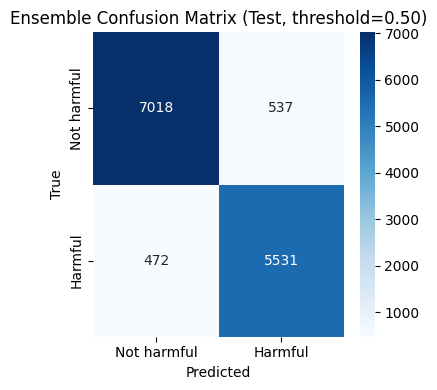

In [16]:
if opt_weights is not None:
    ens_logits_test = ensemble_logits(test_logits_all, opt_weights, "binary")
    ens_probs_test  = F.softmax(ens_logits_test, -1)[:, 1].numpy()

    y_pred_tuned   = (ens_probs_test >= best_thresh).astype(int)
    y_pred_default = (ens_probs_test >= 0.50).astype(int)

    print("="*60)
    print("FINAL ENSEMBLE RESULTS — TEST SET")
    print("="*60)

    for label, preds in [("Default (0.50)", y_pred_default),
                         (f"Tuned ({best_thresh:.2f})", y_pred_tuned)]:
        acc  = accuracy_score(y_test_binary, preds)
        mf1  = f1_score(y_test_binary, preds, average="macro",    zero_division=0)
        wf1  = f1_score(y_test_binary, preds, average="weighted", zero_division=0)
        mcc  = matthews_corrcoef(y_test_binary, preds)
        try:
            auc  = roc_auc_score(y_test_binary, ens_probs_test)
            ap   = average_precision_score(y_test_binary, ens_probs_test)
        except Exception:
            auc = ap = float("nan")
        print(f"\n  {label}")
        print(f"    Accuracy={acc:.4f}  Macro-F1={mf1:.4f}  W-F1={wf1:.4f}")
        print(f"    MCC={mcc:.4f}  AUROC={auc:.4f}  AUPRC={ap:.4f}")

    # ── Save ensemble test metrics for NB07 ───────────────────────
    ens_metrics = {
        "threshold":   float(best_thresh),
        "accuracy":    float(accuracy_score(y_test_binary, y_pred_default)),
        "macro_f1":    float(f1_score(y_test_binary, y_pred_default, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_test_binary, y_pred_default, average="weighted", zero_division=0)),
        "mcc":         float(matthews_corrcoef(y_test_binary, y_pred_default)),
        "auroc":       float(roc_auc_score(y_test_binary, ens_probs_test)),
        "auprc":       float(average_precision_score(y_test_binary, ens_probs_test)),
    }
    with open("../outputs/ensemble/ensemble_test_metrics.json", "w") as _f:
        json.dump(ens_metrics, _f, indent=2)
    print("\n✅ ensemble_test_metrics.json saved")
    print(json.dumps(ens_metrics, indent=2))

    # ── Confusion matrix ──────────────────────────────────────────
    cm = confusion_matrix(y_test_binary, y_pred_default)
    fig, ax = plt.subplots(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not harmful","Harmful"],
                yticklabels=["Not harmful","Harmful"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Ensemble Confusion Matrix (Test, threshold=0.50)")
    plt.tight_layout()
    plt.savefig("../outputs/ensemble/cm_ensemble_test.png", dpi=120, bbox_inches="tight")
    plt.show()


## 5 — Abuse Type Ensemble Evaluation

In [17]:
# Evaluate abuse_type ensemble using consolidated y_true (matches 9-class logits)
if opt_weights is not None and all("abuse_type" in v for v in val_logits_all.values()):
    ens_abu_test = ensemble_logits(test_logits_all, opt_weights, "abuse_type")
    abu_preds    = ens_abu_test.argmax(-1).numpy()

    valid = y_test_abuse >= 0
    abu_f1 = f1_score(y_test_abuse[valid], abu_preds[valid],
                      average="macro", zero_division=0)
    abu_acc = accuracy_score(y_test_abuse[valid], abu_preds[valid])

    print(f"Abuse-type ensemble  macro-F1 = {abu_f1:.4f}   accuracy = {abu_acc:.4f}")
    print("\nPer-class report:")
    abuse_classes = sorted(label_encoders["abuse_type"], key=lambda k: label_encoders["abuse_type"][k])
    print(classification_report(y_test_abuse[valid], abu_preds[valid],
                                  target_names=abuse_classes, zero_division=0))
else:
    print("Abuse-type logits not available or weights not optimised.")


Abuse-type ensemble  macro-F1 = 0.7746   accuracy = 0.8688

Per-class report:
              precision    recall  f1-score   support

     abusive       0.76      0.75      0.76      1600
      gender       0.59      0.53      0.56        90
        none       0.93      0.93      0.93      7830
       other       0.74      0.80      0.77        79
    personal       0.79      0.78      0.78      1344
   political       0.75      0.77      0.76       259
   religious       0.89      0.86      0.87       908
      sexual       0.79      0.81      0.80      1083
      threat       0.73      0.77      0.75       365

    accuracy                           0.87     13558
   macro avg       0.77      0.78      0.77     13558
weighted avg       0.87      0.87      0.87     13558



## 6 — Save Final Config

In [18]:
if opt_weights is not None:
    names = list(val_logits_all.keys())
    cfg = {
        "ensemble_type": "weighted_logits_average",
        "weights": dict(zip(names, [float(w) for w in opt_weights])),
        "threshold": float(best_thresh),
        "n_models": len(val_logits_all),
    }
    with open("../outputs/ensemble/final_config.json","w") as _f:
        json.dump(cfg, _f, indent=2)
    print("✅ final_config.json saved")
    print(json.dumps(cfg, indent=2))

    # ── Required by NB07 error analysis ───────────────────────────
    np.save("../outputs/ensemble/test_preds.npy", y_pred_default)
    np.save("../outputs/ensemble/test_probs.npy", ens_probs_test)
    print("✅ test_preds.npy and test_probs.npy saved")


✅ final_config.json saved
{
  "ensemble_type": "weighted_logits_average",
  "weights": {
    "banglabert_seed123": 0.0421841558960957,
    "banglabert_seed42": 0.28165590203786495,
    "banglabert_seed456": 0.11634941878810545,
    "muril_seed123": 0.11866164792739331,
    "muril_seed42": 0.1679907235213609,
    "muril_seed456": 0.06644375012813063,
    "xlmr_seed123": 0.010678494420421002,
    "xlmr_seed42": 0.033577693260567004,
    "xlmr_seed456": 0.16245821402006094
  },
  "threshold": 0.5000000000000002,
  "n_models": 9
}
✅ test_preds.npy and test_probs.npy saved


---
**Next:** `07_ablations_and_analysis.ipynb`